# Multimodal Pipeline for RAG

## Phase 0: Setting up the Project

In [ ]:
!brew install poppler tesseract libmagic
%pip install "unstructured[pdf, md]" pillow pdf2image

In [22]:
%pip install --upgrade --quiet  langchain langchain-openai langchain-community
%pip install dotenv
%pip install pymongo

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.7/965.7 kB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pymongo]m1/2 [pymongo]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -Uq chromadb tiktoken langchain-community langchain-chroma


Note: you may need to restart the kernel to use updated packages.


## Phase 1: Indexing

Indexing starts with the cleaning and extraction of raw data in diverse formats like PDF, HTML, Word, and Markdown, which is then converted into a uniform plain text format.

In [3]:
import os
from pathlib import Path
file_path = "./backend/assets/MTS2916A.pdf"

### Extraction

#### 1. Approach: Unstructered partition_pdf() Function
-> Tables where not extracted correctly

In [ ]:
from unstructured.partition.pdf import partition_pdf

chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,
    strategy="hi_res",                      # 'hi_res' or 'ocr_only'
    #hi_res_model_name='detectron2_onnx',   # 'yolox' has problems identifying tables! other options are 'detectron2_onnx'
    extract_image_block_types=["Image"],
    extract_image_block_to_payload=True,   # If True, will extract base64 for API usage
    
    chunking_strategy='by_title',          # splitting strategy for the document (related elements are now grouped together) other options are 'basic'or 'by_title,
    max_characters=50000,                  # defaults to 500
    max_partition=None,
    #combine_text_under_n_chars=2000,       # defaults to 0
    #new_after_n_chars=6000,
    )

With the recent updates to the unstructured library (especially >=0.11.x), when using chunking_strategy="by_title", the output elements are wrapped as CompositeElement, grouping together content under headings — which can include Table, Text, Image, etc.

🔍 When to Use Raw Access (No Chunking)

✅ Use this when:
	•	Your primary goal is to extract specific elements, like tables, without worrying about their surrounding context.
	•	You want to classify, transform, or analyze tables or text independently.
	•	You’re building a pipeline where you process each element individually (e.g., sending them to LLMs, storing in a vector DB, etc.).

✅ Pros:
	•	Simple and straightforward.
	•	Full visibility into all content types.
	•	Easier debugging and testing.

❌ Cons:
	•	No semantic grouping — loses the logical structure (e.g., which section the table belongs to).

🧩 When to Use Chunking (e.g. by_title)

✅ Use this when:
	•	You want to preserve the document’s logical structure — e.g., sections, headings, context.
	•	You’re building a retrieval system, summarizer, or LLM pipeline that benefits from cohesive, meaningful chunks.
	•	You want to preserve the relationship between paragraphs and tables/images under a specific section.

✅ Pros:
	•	More semantically meaningful.
	•	Better input for language models.
	•	Maintains context between related elements.

❌ Cons:
	•	More complex to work with — requires digging into CompositeElement.elements.
	•	Slightly harder to extract just tables.

“Basic” chunking strategy: This method allows you to combine sequential elements to maximally fill each chunk while respecting the maximum chunk size limit. If a single isolated element exceeds the hard-max, it will be divided into two or more chunks.

“By title” chunking strategy: This strategy leverages the document element types identified during partitioning to understand the document structure, and preserves section boundaries. This means that a single chunk will never contain text that occurred in two different sections, ensuring that topics remain self-contained for enhanced retrieval precision. 

#### 2. Approach: Unstructured partition_image()
-> OCR Approach didn't deliver any better results

In [ ]:
from pdf2image import convert_from_path
from unstructured.partition.image import partition_image
from PIL import Image
import pytesseract

images = convert_from_path(file_path, dpi=750)

In [ ]:
chunks = []

for image in images:
    image.save("page.jpg", "JPEG")
    image = Image.open("page.jpg")
   
    element = partition_image(
        filename="page.jpg",
        strategy="hi_res",
        infer_table_structure=True,
    )

    chunks.append(element)

In [ ]:
chunks

In [ ]:
#pdf_elements is a list full of chunks. the different elements are stored in the metadata attribute of each chunk so next we have to extract the elements from the metadata with a loop

#pdf_elements[0].metadata.orig_elements


### For Approach 1-2: Separate extracted elements into tables, text and images

#### Separate tables from texts

In [ ]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "CompositeElement" in str(type(chunk)):
        for el in chunk.metadata.orig_elements:
            if "Table" in str(type(el)):
                tables.append(el)
                #remove table from chunk
                chunk.metadata.orig_elements.remove(el)

In [ ]:
tables_html = [table.metadata.text_as_html for table in tables]
tables_html[1]

In [ ]:
# For Testing only!
# Search for Table in chunk
for chunk in chunks:
    if "Table" in str(type(chunk)):
        print("Found Table in chunk")
        print(chunk.metadata.orig_elements)
        #print(chunk.metadata

#### Get the images from the CompositeElement objects

In [ ]:
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
                    chunk.metadata.orig_elements.remove(el)
    return images_b64

images = get_images_base64(chunks)

In [ ]:
#Check if images are still in the chunks
for chunk in chunks:
    if "Image" in str(type(chunk)):
        print("Found Image in chunk")
        print(chunk.metadata.orig_elements)
        #print(chunk.metadata.orig_elements

#### The rest is text

In [ ]:
# The rest of the chunks are text
texts = []
for chunk in chunks:
    texts.append(chunk)

In [ ]:
#print(texts[0])

### 3. Approach: Mistral OCR API
-> Using Mistral OCR API for document processing and text extraction delivered the best results.

In [ ]:
%pip install mistralai

In [ ]:
from mistralai import Mistral
from pathlib import Path
from mistralai import DocumentURLChunk, ImageURLChunk, TextChunk
import json

api_key = os.environ.get("MISTRAL_API_KEY")
client = Mistral(api_key=api_key)

pdf_file = file_path

# Upload PDF file to Mistral's OCR service
uploaded_file = client.files.upload(
    file={
        "file_name": pdf_file,
        "content": open(pdf_file, "rb"),
    },
    purpose="ocr",
)

# Get URL for the uploaded file
signed_url = client.files.get_signed_url(file_id=uploaded_file.id, expiry=1)

# Process PDF with OCR, including embedded images
pdf_response = client.ocr.process(
    document=DocumentURLChunk(document_url=signed_url.url),
    model="mistral-ocr-latest",
    include_image_base64=True
)

# Convert response to JSON format
response_dict = json.loads(pdf_response.model_dump_json())

In [ ]:
response_dict

Separate markdown and images into lists

In [ ]:
markdown = []
images = []

for page in response_dict["pages"]:
    markdown.append(page["markdown"])
    if page["images"] is not None:
        for image in page["images"]:
            images.append(image["image_base64"])

Try to partition the markdown into text and tables with unstructured

In [ ]:
from unstructured.partition.md import partition_md

file_path = "test.md"

chunks = partition_md(
    filename=file_path,
)

In [ ]:
chunks

In [ ]:
tables = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)
        chunks.remove(chunk)

In [ ]:
print(tables[1].text)

##### Test Function to recreate the pdf and check the results

In [ ]:
# with open('test.md', 'w') as f:
#         for text in markdown:
#             f.write(text)

In [ ]:
import base64

def data_uri_to_bytes(data_uri):
    _, encoded = data_uri.split(',', 1)
    return base64.b64decode(encoded)

def export_image(image):
    parsed_image = data_uri_to_bytes(image["image_base64"])
    with open(image["id"], 'wb') as file:
        file.write(parsed_image)

with open('output.md', 'w') as f: 
    for page in response_dict["pages"]:
        f.write(page["markdown"])
        for image in page["images"]:
            export_image(image)

### 4. Approach: Docling

In [4]:
%pip install docling
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [5]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

pipeline_options = PdfPipelineOptions()
pipeline_options.do_picture_description = True
pipeline_options.generate_picture_images = True
pipeline_options.images_scale = 2
pipeline_options.do_picture_classification = True


converter = DocumentConverter(format_options={
    InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
})

source = file_path
result = converter.convert(source)

doc = result.document

/Users/maxtyrchan/Developer/hdm/DesignSpecs-RAG/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/maxtyrchan/Developer/hdm/DesignSpecs-RAG/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/maxtyrchan/Developer/hdm/DesignSpecs-RAG/.venv/lib/python3.13/site-packages/docling/pipeline/standard_pdf_pipeline.py:262: RuntimeWarning: Mean of empty slice
  np.nanmean(
/Users/maxtyrchan/Developer/hdm/DesignSpecs-RAG/.venv/lib/python3.13/site-packages/docling/pipeline/standard_pdf_pipeline.py:267: RuntimeWarning: Mean of empty slice
  np.nanmean(


In [ ]:
doc = result.document
print(doc.export_to_markdown())

#### Extract Tables

In [6]:
tables = []

for table in doc.tables:
    tables.append(table.export_to_markdown(doc))

print(len(tables))

#### Extract the Images

In [7]:
import base64

output_dir = Path("backend/assets/figures")
doc_filename = result.input.file.stem

# Create the output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

image_summaries = []
images = []

picture_counter = 0
for picture in doc.pictures:
    picture_counter += 1
    img = picture.get_image(doc)
    
    # Skips all Logo's
    if any(annotation.kind == "description" for annotation in picture.annotations):
        try:
            b64 = picture._image_to_base64(img)
            decoded_image = base64.b64decode(b64, validate=True)
            if decoded_image:
                images.append(b64)
        except Exception as e:
            print(f"Error decoding image: {e}")
        element_image_filename = (
            output_dir / f"{doc_filename}-picture-{picture_counter}.png")
        with element_image_filename.open("wb") as fp:
            picture.get_image(doc).save(fp, "PNG")
        for annotation in picture.annotations:
            if annotation.kind == "description":
                print(f"Image description: {annotation.text}")
                image_summaries.append(annotation.text)
    else:
        pass

Image description: The image depicts a sequence of steps that are part of a process or a series of steps. The sequence is structured in a logical and sequential manner, with each step connected to the previous one. Here is a detailed breakdown of the sequence:

### Image Description:

- **Phase 1:**
  - **Phase 1:** The first step is the **VLOD** (Voltage Load) which is connected to the **Logic** (Logic) component.
  - **Logic:** The **Logic** component is connected to the **VREF** (V-Reference) component.
  - **VREF:** The **VREF** component is connected to the **Logic** component.
  - **Logic:** The **Logic** component is connected to the **VREF** component.
  - **VREF:** The **VREF** component is connected to the **Logic** component.
  - **Logic:** The **
Image description: In this image, we can see a diagram with some text and some numbers.
Image description: The image shows a diagram with a series of arrows pointing from one arrow to another. The arrows are labeled with the follow

## Phase 2: Chunking & Contextualization

Adding context to both images and tables as well as text for enhanced retrieval and understanding.<br>
Proposed by Anthropic "contextual-retrieval" approach.

In [114]:
from langchain_openai import AzureChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from dotenv import load_dotenv
from langchain_core.rate_limiters import InMemoryRateLimiter

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.5,
    check_every_n_seconds=1,
    max_bucket_size=500000,
)
load_dotenv()
azure_api_key = os.getenv("AZURE_OPENAI_API_KEY")
azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")

### Summarization of Tables (Skip this step when using Docling)

In [8]:
# Prompt
prompt_text ="""
You are a helpful assistant tasked with summarizing tables precisely.
Give a concise summary of the table.

Respond only with the summary, no additional comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table: {element}

"""
#rate_limiter=rate_limiter,

# Summary chain
model = AzureChatOpenAI(
    azure_deployment="gpt-4o",
    api_version="2024-12-01-preview",
    azure_endpoint=azure_endpoint,
    api_key=azure_api_key,
    temperature=0,
    model="gpt-4o"
)

prompt = ChatPromptTemplate.from_template(prompt_text)

#summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()
summarize_chain = prompt | model | StrOutputParser()

In [ ]:
# Only for Approach 1 & 2
# tables_html = [table.metadata.text_as_html for table in tables]
# tables_html[1]

In [9]:
table_summaries = summarize_chain.batch(tables, {"max_concurrency": 3})

### Summarization of Images (Skip this step when using Docling)

In [ ]:
prompt_template = """You are a helpful assistant tasked with describing a image in detail. For context, the image is part of a design specification explaining the design of a digital temperature sensor.
Respond only with the description, no additional comment. Do not start your message by saying "Here is a description" or anything like that. Just give the description as it is."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | model | StrOutputParser()

image_summaries = chain.batch(images)

### Contextualization of Chunks

In [12]:
from docling.chunking import HybridChunker
import tiktoken
from docling_core.transforms.chunker.tokenizer.openai import OpenAITokenizer
from docling_core.transforms.chunker.hierarchical_chunker import (
    ChunkingDocSerializer,
    ChunkingSerializerProvider,
)
from docling_core.transforms.serializer.markdown import MarkdownTableSerializer
from docling_core.transforms.serializer.markdown import MarkdownParams

from typing import Any

from docling_core.transforms.serializer.base import (
    BaseDocSerializer,
    SerializationResult,
)
from docling_core.transforms.serializer.common import create_ser_result
from docling_core.transforms.serializer.markdown import MarkdownPictureSerializer
from docling_core.types.doc.document import (
    PictureClassificationData,
    PictureDescriptionData,
    PictureItem,
    PictureMoleculeData,
)
from typing_extensions import override

class SerializerProvider(ChunkingSerializerProvider):
    def get_serializer(self, doc):
        return ChunkingDocSerializer(
            doc=doc,
            # configuring a different table serializer
            table_serializer=MarkdownTableSerializer(),
            # Leave out images eventually because we already have them in the image_summaries
            # params=MarkdownParams(
            # image_placeholder="<!-- image -->",
            # ),
        )

tokenizer = OpenAITokenizer(
    tokenizer=tiktoken.encoding_for_model("gpt-4o"),
    max_tokens=128 * 1024,  # context window length required for OpenAI tokenizers
)

chunker = HybridChunker(
    tokenizer=tokenizer,
    merge_peers=True,  # optional, defaults to True
    serializer_provider=SerializerProvider(),
    )

chunk_iter = chunker.chunk(dl_doc=doc)
chunks = list(chunk_iter)

In [13]:
from typing import Iterable, Optional

from docling_core.transforms.chunker.base import BaseChunk
from docling_core.transforms.chunker.hierarchical_chunker import DocChunk
from docling_core.types.doc.labels import DocItemLabel
from rich.console import Console
from rich.panel import Panel

console = Console(
    width=200,  # for getting Markdown tables rendered nicely
)


def find_n_th_chunk_with_label(
    iter: Iterable[BaseChunk], n: int, label: DocItemLabel
) -> Optional[DocChunk]:
    num_found = -1
    for i, chunk in enumerate(iter):
        doc_chunk = DocChunk.model_validate(chunk)
        for it in doc_chunk.meta.doc_items:
            if it.label == label:
                num_found += 1
                if num_found == n:
                    return i, chunk
    return None, None


def print_chunk(chunks, chunk_pos):
    chunk = chunks[chunk_pos]
    ctx_text = chunker.contextualize(chunk=chunk)
    num_tokens = tokenizer.count_tokens(text=ctx_text)
    doc_items_refs = [it.self_ref for it in chunk.meta.doc_items]
    title = f"{chunk_pos=} {num_tokens=} {doc_items_refs=}"
    console.print(Panel(ctx_text, title=title))

Print Images

In [ ]:
i, chunk = find_n_th_chunk_with_label(chunks, n=0, label=DocItemLabel.PICTURE)
print_chunk(
    chunks=chunks,
    chunk_pos=i,
)

Print Tables:

In [14]:
i, chunk = find_n_th_chunk_with_label(chunks, n=0, label=DocItemLabel.TABLE)
print_chunk(
    chunks=chunks,
    chunk_pos=i,
)

╭────────────────────────────────────────────────────────────────────── chunk_pos=3 num_tokens=186 doc_items_refs=['#/tables/0'] ──────────────────────────────────────────────────────────────────────╮
│ Package Types                                                                                                                                                                                        │
│ | 1 I02 MTS2916A SOP-24   | 24 V LOAD   |                                                                                                                                                            │
│ |-------------------------|-------------|                                                                                                                                                            │
│ | 2 I12                   | 23 OUT2B    |                                                                                                                                                            │
│ | 3 PHASE2                | 22 COMPIN2  |                                                                                                                                                            │
│ | 4 V REF2                | 21 SENSE2   |                                                                                                                                                            │
│ | 5 RC2                   | 20 OUT2A    |                                                                                                                                                            │
│ | 6 GND                   | GND 19      |                                                                                                                                                            │
│ | 7 GND                   | 18 GND      |                                                                                                                                                            │
│ | 8 V LOGIC               | 17 OUT1A    |                                                                                                                                                            │
│ | 9 RC1                   | 16 SENSE1   |                                                                                                                                                            │
│ | 10 V REF1               | COMPIN1 15  |                                                                                                                                                            │
│ | PHASE1 11               | OUT1B 14    |                                                                                                                                                            │
│ | I11 12                  | I01 13      |                                                                                                                                                            │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [107]:
texts = []
text_summaries = []

tables = []
table_summaries = []

for i, chunk in enumerate(chunks):
    txt_tokens = tokenizer.count_tokens(chunk.text)
    ser_txt = chunker.contextualize(chunk=chunk)
    ser_tokens = tokenizer.count_tokens(ser_txt)
    print(f"=== {i} ===")
    print(f"chunk.text ({txt_tokens} tokens):\n{chunk.text!r}")
    print(f"chunker.contextualize(chunk) ({ser_tokens} tokens):\n{ser_txt!r}")
    print()
    for it in chunk.meta.doc_items:
        if it.label == DocItemLabel.PICTURE:
            break
        if it.label == DocItemLabel.TABLE:
            tables.append(chunk.text)
            table_summaries.append(ser_txt)
            break
        if it.label == DocItemLabel.TEXT:
            texts.append(chunk.text)
            text_summaries.append(ser_txt)
            break

        

=== 0 ===
chunk.text (1 tokens):
'logo'
chunker.contextualize(chunk) (1 tokens):
'logo'

=== 1 ===
chunk.text (117 tokens):
'· 750 mA Continuous Output Current\n· Load Voltage Supply: 10V to 40V\n· Full Bipolar Stepper Motor Drive Capability\n· Bidirectional DC Motor Capability\n· Internal Fixed T OFF  Time PWM Current Control\n· Internal Protection Diodes\n· Internal Thermal Shutdown\n· Under Voltage Lockout\n· LS-TTL Compatible Logic Inputs with Pull-Up Resistors\n· Low R ON  Output Resistance\n· Low Quiescent Current\n· Operating Temperature Range: -40°C to +105°C\n· Pin Compatible with Allegro 2916'
chunker.contextualize(chunk) (119 tokens):
'Description\n· 750 mA Continuous Output Current\n· Load Voltage Supply: 10V to 40V\n· Full Bipolar Stepper Motor Drive Capability\n· Bidirectional DC Motor Capability\n· Internal Fixed T OFF  Time PWM Current Control\n· Internal Protection Diodes\n· Internal Thermal Shutdown\n· Under Voltage Lockout\n· LS-TTL Compatible Logic Inputs with Pull-

##### NOT for Docling approach!
#Consider Prompt caching!

In [ ]:
document_context_prompt = """
<document>
{doc_content}
</document>
"""

chunk_context_prompt = """
Here is the chunk we want to situate within the whole document
<chunk>
{chunk_content}
</chunk>

Please give a short succinct context to situate this chunk within the overall document for the purposes of improving search retrieval of the chunk.
Answer only with the succinct context and nothing else.
"""

messages = [
    (
        "user",
        [
            {"type": "text", "text": document_context_prompt.format(doc_content=doc.export_to_markdown())},
            {
                "type": "text",
                "text": chunk_context_prompt.format(chunk_content="{texts}"),
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | model | StrOutputParser()

chunks_context = chain.batch(texts)

## Phase 3: Vectorization

### Create Vectorstore

In [68]:
!rm -rf backend/db

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


##### Local Store

In [109]:
import uuid
from pathlib import Path
from langchain_chroma import Chroma
import chromadb
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain_openai import AzureOpenAIEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever

azure_embeddings_endpoint = os.getenv("AZURE_OPENAI_EMBEDDINGS_ENDPOINT")

embeddings = AzureOpenAIEmbeddings(
    model="text-embedding-3-large",
    api_version="2024-12-01-preview",
    azure_endpoint=azure_embeddings_endpoint,
    api_key=azure_api_key,
)

vectorstore = Chroma(collection_name="DesignSpecsRAG",
                     embedding_function=embeddings,
                     )

# The storage layer for the parent documents
store = InMemoryStore()

id_key = "doc_id"
text_item = "text_item"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

#### Persistent Store

In [ ]:
import uuid
from pathlib import Path
from langchain_chroma import Chroma
import chromadb
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain_openai import AzureOpenAIEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import LocalFileStore
import shutil

azure_embeddings_endpoint = os.getenv("AZURE_OPENAI_EMBEDDINGS_ENDPOINT")

embeddings = AzureOpenAIEmbeddings(
    model="text-embedding-3-large",
    api_version="2024-12-01-preview",
    azure_endpoint=azure_embeddings_endpoint,
    api_key=azure_api_key,
)

vectorstore_dir = Path("backend/db/chroma")
if vectorstore_dir.exists():
    shutil.rmtree(vectorstore_dir)

docs_dir = Path("backend/db/docs")
vectorstore_dir.mkdir(parents=True, exist_ok=True)
docs_dir.mkdir(parents=True, exist_ok=True)

client = chromadb.PersistentClient(
    path=str(vectorstore_dir),
    settings=chromadb.Settings(
        allow_reset=True,  # Allows creation of new database
        is_persistent=True
    )
)

vectorstore = Chroma(collection_name="DesignSpecsRAG",
                     embedding_function=embeddings,
                     #persist_directory=vectorstore_dir
                     client=client
                     )

# The storage layer for the parent documents
store = LocalFileStore(root_path=str(docs_dir))

id_key = "doc_id"
text_item = "text_item"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

ValueError: An instance of Chroma already exists for backend/db/chroma with different settings

### Load Data

In [111]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i], text_item: texts[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

Note: Use open source Retriever like ChromaDB for open source!

#### Check Retriever

schema_name='DoclingDocument' version='1.3.0' name='MTS2916A' origin=DocumentOrigin(mimetype='application/pdf', binary_hash=5171745011735823367, filename='MTS2916A.pdf', uri=None) furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>) body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/texts/3'), RefItem(cref='#/groups/0'), RefItem(cref='#/texts/17'), RefItem(cref='#/groups/1'), RefItem(cref='#/groups/2'), RefItem(cref='#/texts/24'), RefItem(cref='#/texts/25'), RefItem(cref='#/texts/26'), RefItem(cref='#/texts/27'), RefItem(cref='#/texts/28'), RefItem(cref='#/tables/0'), RefItem(cref='#/texts/29'), RefItem(cref='#/texts/30'), RefItem(cref='#/texts/31'), RefItem(cref='#/texts/32'), RefItem(cref='#/pictures/1'), RefItem(cref='#/te
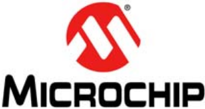
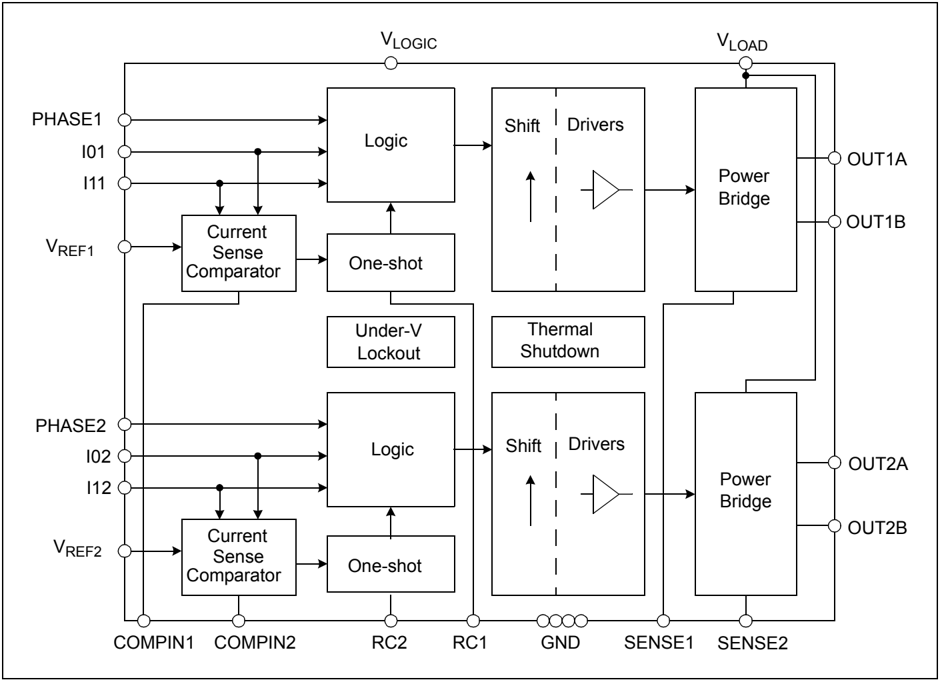
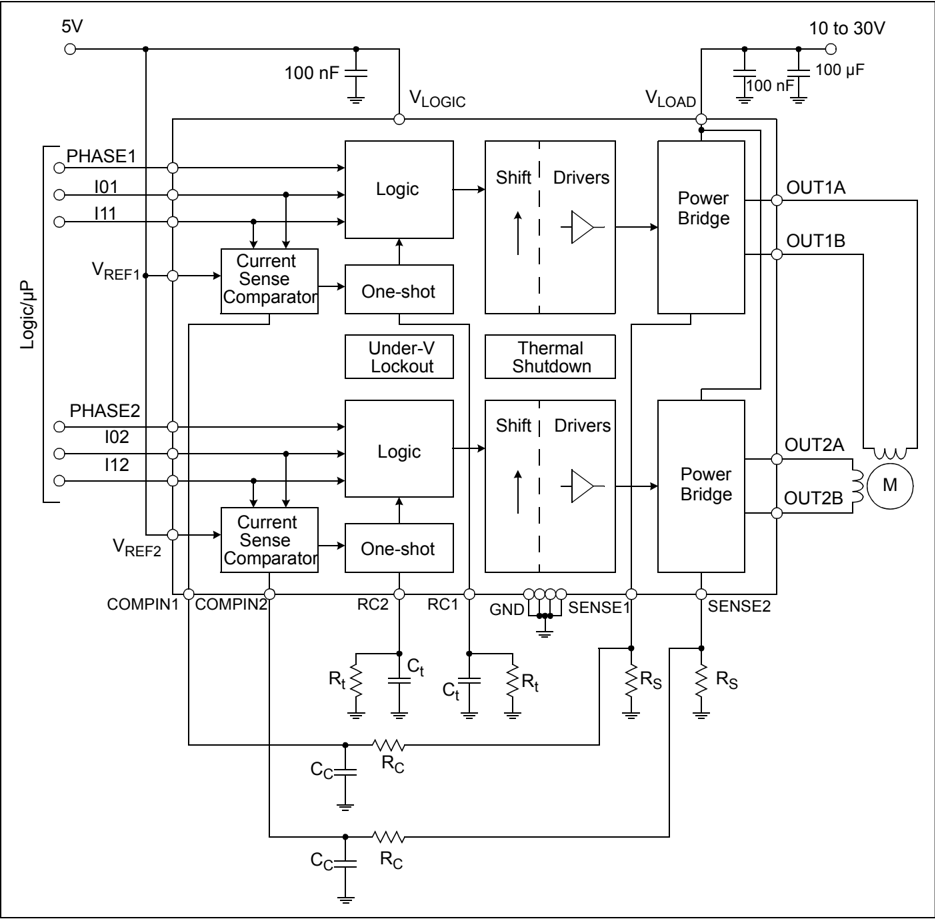
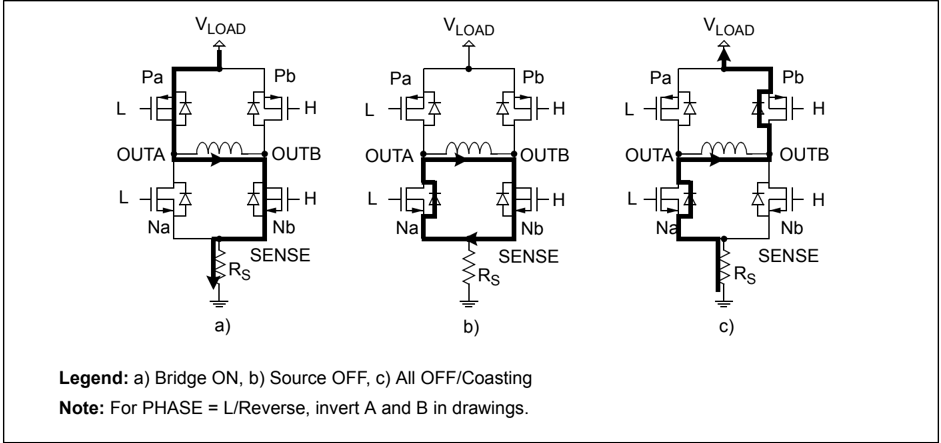
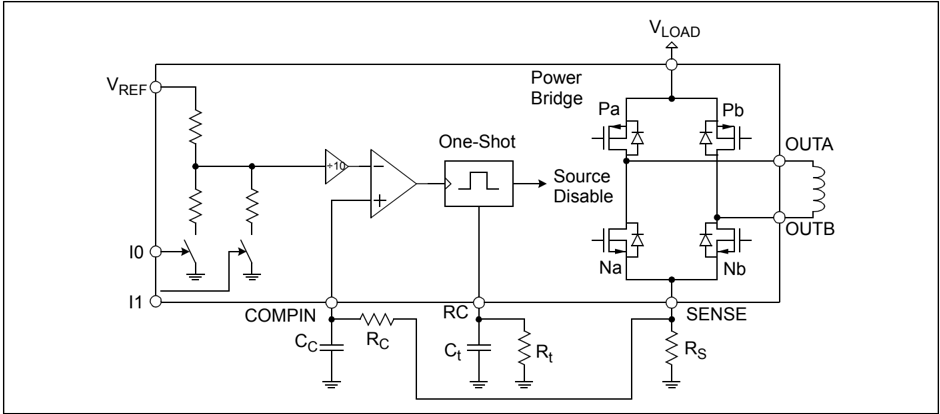
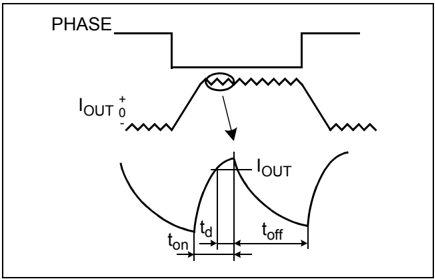
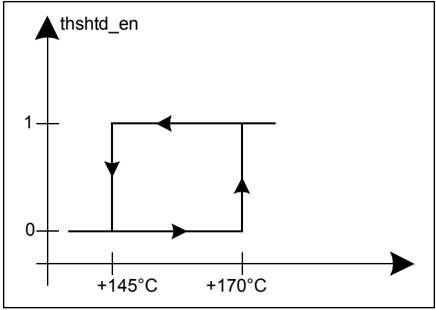
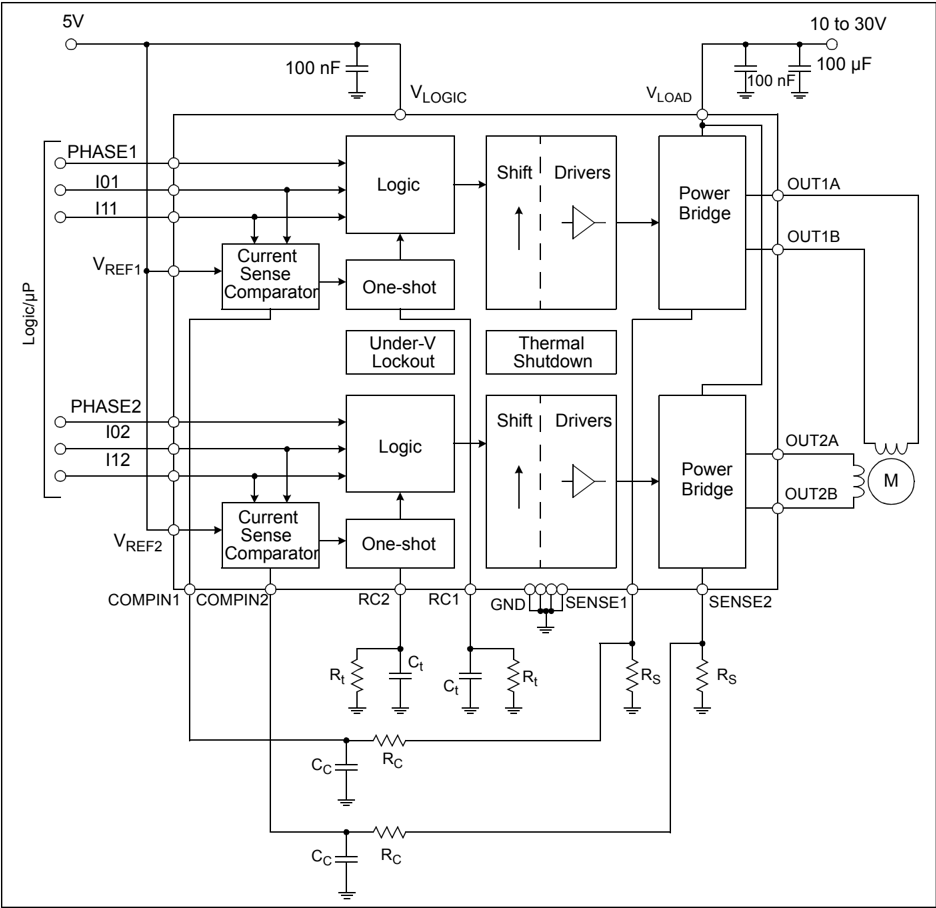
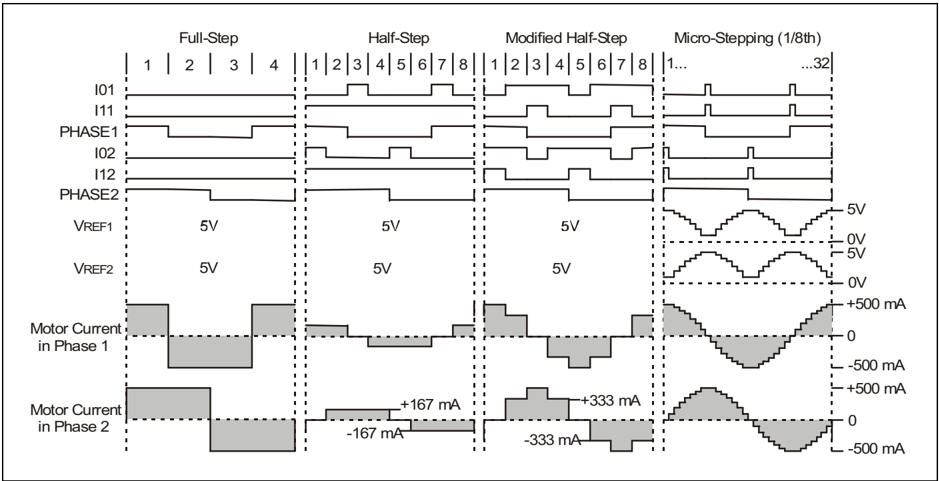
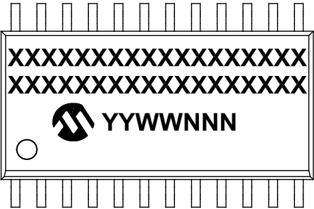
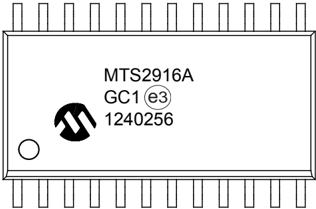
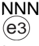
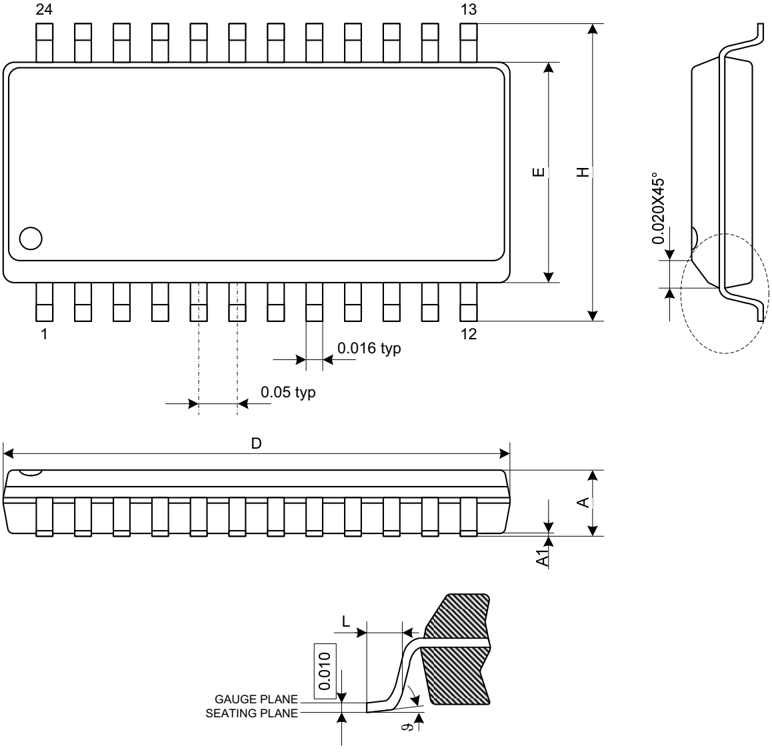
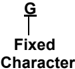
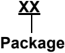
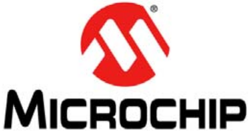

In [112]:
# Retrieve
chunks = retriever.invoke(
    "What is the MTS2916A"
)

for chunk in chunks:
    print(str(doc) + "\n\n" + "-" * 80)

## Phase 4: RAG Pipeline

In [115]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import AzureChatOpenAI
from base64 import b64decode


def parse_answer(answers):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for answer in answers:
        try:
            b64decode(answer)
            b64.append(answer)
        except Exception as e:
            text.append(answer)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    answers_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(answers_by_type["texts"]) > 0:
        for text_element in answers_by_type["texts"]:
            context_text += text_element

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(answers_by_type["images"]) > 0:
        for image in answers_by_type["images"]:
            try:
                # Try decoding to make sure it is valid base64
                decoded_image = base64.b64decode(image, validate=True)
                if decoded_image:
                    prompt_content.append(
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                        }
                        )
            except Exception as e:
                print(f"⚠️ Skipping invalid image: {e}")

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_answer),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | AzureChatOpenAI(api_version="2024-12-01-preview",
                      azure_endpoint=azure_endpoint,
                      api_key=azure_api_key,
                      temperature=0,
                      model="gpt-4o")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_answer),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | AzureChatOpenAI(api_version="2024-12-01-preview",
                          azure_endpoint=azure_endpoint,
                          api_key=azure_api_key,
                          temperature=0,
                          model="gpt-4o")
        | StrOutputParser()
    )
)

In [116]:
response = chain.invoke(
    "When are the power transistors disabled?"
)

print(response)

The power transistors are disabled in two scenarios:

1. **Thermal Protection**: The thermal protection circuitry disables all drivers when the junction temperature exceeds +170°C (typical). The drivers are re-enabled once the junction temperature drops below +145°C (typical).

2. **Undervoltage Lockout**: The power bridge and all outputs are disabled if the logic supply voltage (VLOGIC) is smaller than 4V. This protects the circuit from potential shoot-through currents when the load supply voltage is applied before the logic supply voltage.


In [117]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

In [118]:
response = chain_with_sources.invoke(
    "What is the Power Bridge Operation of the MTS2916A?",
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

Response: The Power Bridge Operation of the MTS2916A refers to its ability to drive two independent stepper motors or a single stepper motor in a full-bridge configuration. This operation involves controlling the current flow through the motor windings using H-bridge circuits, allowing precise control of motor movement and torque.


Context:
NOTES:

--------------------------------------------------

NOTES:

--------------------------------------------------

